In [1]:
import shutil

import duckdb
import pandas as pd
from networks.oligoclonal_network import OligoclonalModel


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value, set, interpretation,label
                 FROM protein_data
                 WHERE observation_nr = 1
                 """).df()
con.close()

correct_label = df['label'] == 6

valid_text = df['interpretation'].apply(lambda x: 1 if 'oligoklonal' in str(x).lower() else 0)
df['label'] = ((correct_label) | (valid_text)).astype(int)


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

extra_val = train_rows.sample(frac=0.2, random_state=42)
train_rows = train_rows.drop(extra_val.index)
val_rows = pd.concat([val_rows, extra_val], ignore_index=True)

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.8).index

train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan oligoklonalt-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med oligoklonalt i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

print(f"-----\nAntal utan oligoklonalt i valideringsdatan: {len(val_rows[val_rows['label'] == 0])}")
print(f"Antal med oligoklonalt i valideringsdatan: {len(val_rows[val_rows['label'] == 1])}")

Oligoclonal = OligoclonalModel()
train_dl = Oligoclonal.build_dataloader(train_rows)
val_dl = Oligoclonal.build_dataloader(val_rows)
test_dl = Oligoclonal.build_dataloader(test_rows)

results = []

best_auc = -1
best_run = None

for run in range(10):
    print(f"Körning {run+1}/10")

    Oligoclonal = OligoclonalModel()


    auc = Oligoclonal.retrain(
        train_dl=train_dl,
        val_dl=val_dl,
        patience=10,
        model_path=f"../models/temp_oligoclonal_{run}.pth"
    )

    results.append({
        "run": run + 1,
        "val_auc": auc
    })

    if auc > best_auc:
        best_auc = auc
        best_run = run + 1
        print(Oligoclonal.model_path)
        shutil.copy(
            f"../models/temp_oligoclonal_{run}.pth",
            Oligoclonal.model_path
        )

result_df = pd.DataFrame(results)
result_df.to_csv("../results/oligoclonal_runs.csv", index=False)

print(result_df)
print(f"Bästa körning: {best_run}")
print(f"Bästa val AUC: {best_auc:.4f}")

Antal utan oligoklonalt-komponent i träningsdatan: 10257
Antal med oligoklonalt i träningsdatan: 1899
-----
Antal utan oligoklonalt i valideringsdatan: 16226
Antal med oligoklonalt i valideringsdatan: 560
Körning 1/10
  -> ny bästa modell sparad till ../models/temp_oligoclonal_0.pth
Epoch   0 | train: 0.6523 | val: 0.5601 | acc: 80.56% | AUC: 0.730  | LR: 0.001
  -> ny bästa modell sparad till ../models/temp_oligoclonal_0.pth
Epoch   1 | train: 0.5847 | val: 0.5936 | acc: 63.28% | AUC: 0.758  | LR: 0.001
  -> ny bästa modell sparad till ../models/temp_oligoclonal_0.pth
Epoch   2 | train: 0.5611 | val: 0.6485 | acc: 63.29% | AUC: 0.785  | LR: 0.001
  -> ny bästa modell sparad till ../models/temp_oligoclonal_0.pth
Epoch   3 | train: 0.5007 | val: 0.6544 | acc: 60.64% | AUC: 0.845  | LR: 0.001
  -> ny bästa modell sparad till ../models/temp_oligoclonal_0.pth
Epoch   4 | train: 0.4380 | val: 0.5321 | acc: 73.37% | AUC: 0.897  | LR: 0.001
  -> ny bästa modell sparad till ../models/temp_olig

In [ ]:
con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value, set, interpretation,label
                 FROM protein_data
                 WHERE  observation_nr = 1
                 """).df()
con.close()

correct_label = df['label'] == 6

valid_text = df['interpretation'].apply(lambda x: 1 if 'oligoklonal' in str(x).lower() else 0)
df['label'] = ((correct_label) | (valid_text)).astype(int)



k_fold_rows = df[df['set'].isin(['train','val']) ].copy()
k_fold_rows = k_fold_rows[k_fold_rows['label'].isin([0,1])]
drop_indices = k_fold_rows[k_fold_rows['label'] == 0].sample(frac=0.8).index
k_fold_rows = k_fold_rows.drop(drop_indices)

print(f"Totalt antal utan oligoklonalt i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 0])}")
print(f"Totalt antal med oligoklonalt i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 1])}")

Oligoclonal = OligoclonalModel()
Oligoclonal.retrain_with_k_fold(k_fold_rows)

Totalt antal utan oligoklonalt i K-fold poolen: 13503
Totalt antal med oligoklonalt i K-fold poolen: 2459
--- Startar 10-Fold Cross Validation ---

 FOLD 1/10
Epoch   0 | train: 0.7205 | val: 0.6866 | acc: 22.60% | AUC: 0.691  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model_fold1.pth
Epoch   1 | train: 0.6755 | val: 0.6639 | acc: 15.59% | AUC: 0.706  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model_fold1.pth
Epoch   2 | train: 0.6569 | val: 0.6160 | acc: 73.39% | AUC: 0.733  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model_fold1.pth
Epoch   3 | train: 0.6145 | val: 0.6152 | acc: 69.51% | AUC: 0.738  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model_fold1.pth
Epoch   4 | train: 0.6073 | val: 0.6194 | acc: 63.37% | AUC: 0.741  | LR: 0.001
Epoch   5 | train: 0.6111 | val: 0.6336 | acc: 65.06% | AUC: 0.743  | LR: 0.001
Epoch   6 | train: 0.6029 | val: 0.6140 | acc: 62.12% | AUC: 0.745  | LR: 0.0

,fold,train_loss,val_loss,val_accuracy,val_auc
0,1,0.225149,0.327441,85.848466,0.934021
1,2,0.325084,0.359100,86.912962,0.925331
2,3,0.260258,0.332700,86.967419,0.941358
3,4,0.260612,0.359413,83.709273,0.937266
4,5,0.267676,0.310881,84.711779,0.933114
5,6,0.266084,0.287013,87.030075,0.944131
6,7,0.262493,0.308846,85.964912,0.942903
7,8,0.296129,0.303502,84.962406,0.931244
8,9,0.283619,0.308318,87.593985,0.940307
9,10,0.269444,0.339998,83.897243,0.935023


Totala mängd datapunkter: 7800
              precision    recall  f1-score   support

     Negativ       0.99      0.92      0.95      7546
     Positiv       0.24      0.72      0.36       254

    accuracy                           0.91      7800
   macro avg       0.61      0.82      0.65      7800
weighted avg       0.97      0.91      0.93      7800

[[6949  597]
 [  70  184]]
AUC: 0.9334924275467421
Accuracy:  91.45%
FN-rate:   27.56%  (farliga missade fall)
FP-rate:   7.91%  (onödiga larm)
Sensitivitet:   72.44%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   92.09%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9335


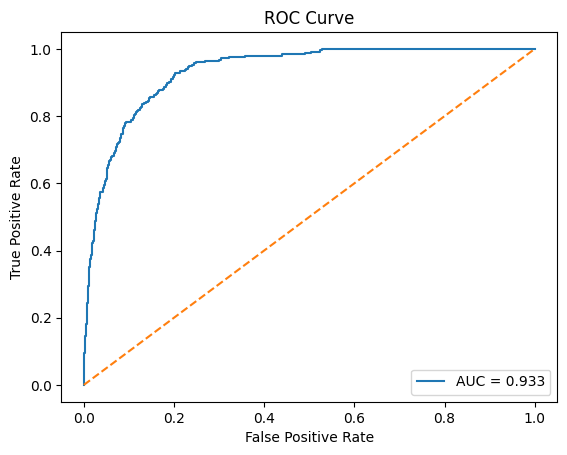

In [ ]:
result = Oligoclonal.predict(test_rows)
df = Oligoclonal.evaluate(result,threshold=0.6)
